# **Social Media and Mental Health Analysis**

# **Objective**

This study investigates how social media usage affects stress levels and sleep quality among different age groups and platforms.

## **Import** **Libraries**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## **Load Dataset**



In [ ]:
from google.colab import files
uploaded = files.upload()


Saving social media and mental health dataset.csv to social media and mental health dataset.csv


,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Social_Media_Platform
0,44.0,Male,3.1,7.0,6.0,Facebook
1,30.0,Other,5.1,7.0,8.0,LinkedIn
2,23.0,Other,7.4,6.0,7.0,YouTube
3,36.0,Female,5.7,7.0,8.0,TikTok
4,34.0,Female,7.0,4.0,7.0,X (Twitter)


In [ ]:
import os
print(os.listdir())

['.config', 'social media and mental health dataset.csv', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("social media and mental health dataset.csv")

df.head()

,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Social_Media_Platform
0,44.0,Male,3.1,7.0,6.0,Facebook
1,30.0,Other,5.1,7.0,8.0,LinkedIn
2,23.0,Other,7.4,6.0,7.0,YouTube
3,36.0,Female,5.7,7.0,8.0,TikTok
4,34.0,Female,7.0,4.0,7.0,X (Twitter)


In [ ]:
df.shape

(617, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     500 non-null    float64
 1   Gender                  500 non-null    object 
 2   Daily_Screen_Time(hrs)  500 non-null    float64
 3   Sleep_Quality(1-10)     500 non-null    float64
 4   Stress_Level(1-10)      500 non-null    float64
 5   Social_Media_Platform   500 non-null    object 
dtypes: float64(4), object(2)
memory usage: 29.1+ KB


## **Data Cleaning**


Before analysis, missing values are removed to ensure accurate results.

In [ ]:
df.isnull().sum()


,0
Age,117
Gender,117
Daily_Screen_Time(hrs),117
Sleep_Quality(1-10),117
Stress_Level(1-10),117
Social_Media_Platform,117


In [ ]:
df = df.dropna()

In [ ]:
df.shape

(500, 6)

In [ ]:
df.columns

Index(['Age', 'Gender', 'Daily_Screen_Time(hrs)', 'Sleep_Quality(1-10)',
       'Stress_Level(1-10)', 'Social_Media_Platform'],
      dtype='object')

### **Creating Screen Time Categories**

In [ ]:
def usage_band(hours):
    if hours <= 2:
        return "Low"
    elif hours <= 5:
        return "Medium"
    else:
        return "High"

df["Usage_Band"] = df["Daily_Screen_Time(hrs)"].apply(usage_band)

In [ ]:
df.head()

,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Social_Media_Platform,Usage_Band
0,44.0,Male,3.1,7.0,6.0,Facebook,Medium
1,30.0,Other,5.1,7.0,8.0,LinkedIn,High
2,23.0,Other,7.4,6.0,7.0,YouTube,High
3,36.0,Female,5.7,7.0,8.0,TikTok,High
4,34.0,Female,7.0,4.0,7.0,X (Twitter),High


## **Exploratory Data Analysis (EDA)**



# **1. Does higher screen time lead to higher stress levels?**

In [ ]:
df.groupby("Usage_Band")["Stress_Level(1-10)"].mean()

,Stress_Level(1-10)
Usage_Band,
High,7.351974
Low,4.333333
Medium,5.534759


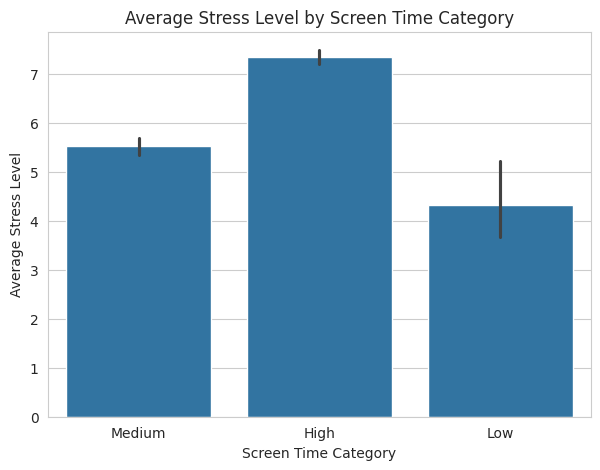

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="Usage_Band",
    y="Stress_Level(1-10)"
)

plt.title("Average Stress Level by Screen Time Category")
plt.xlabel("Screen Time Category")
plt.ylabel("Average Stress Level")

plt.show()

In [ ]:
df.columns

Index(['Age', 'Gender', 'Daily_Screen_Time(hrs)', 'Sleep_Quality(1-10)',
       'Stress_Level(1-10)', 'Social_Media_Platform', 'Usage_Band'],
      dtype='object')

**Interpretation:**

This chart compares average stress levels across Low, Medium, and High social media usage groups. If the High usage group shows a higher average stress level, it suggests that increased screen time may be associated with greater stress.

# **2. Which social media platform has the highest average stress level?**

In [ ]:
platform_stress = (
    df.groupby("Social_Media_Platform")["Stress_Level(1-10)"]
    .mean()
    .sort_values(ascending=False)
)

platform_stress

,Stress_Level(1-10)
Social_Media_Platform,
Instagram,6.959459
Facebook,6.666667
YouTube,6.640000
TikTok,6.589474
LinkedIn,6.459770
X (Twitter),6.454545


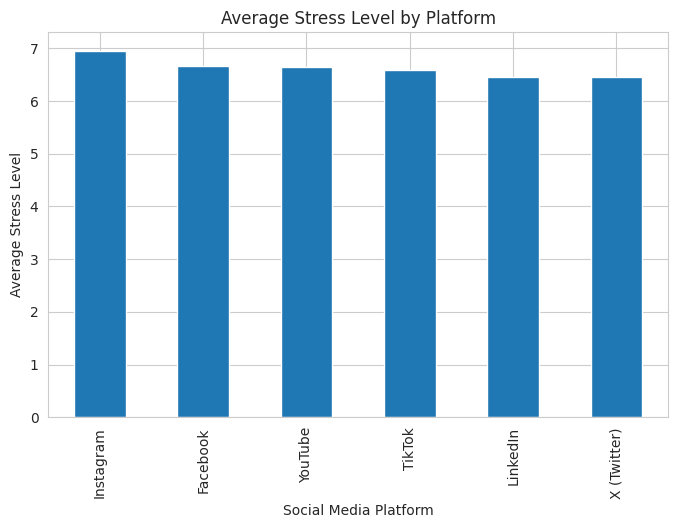

In [ ]:
plt.figure(figsize=(8,5))

platform_stress.plot(kind="bar")

plt.title("Average Stress Level by Platform")
plt.xlabel("Social Media Platform")
plt.ylabel("Average Stress Level")

plt.show()

**Interpretation:**

This analysis identifies which social media platform users report the highest average stress levels.

# **3. Does increased screen time affect sleep quality?**




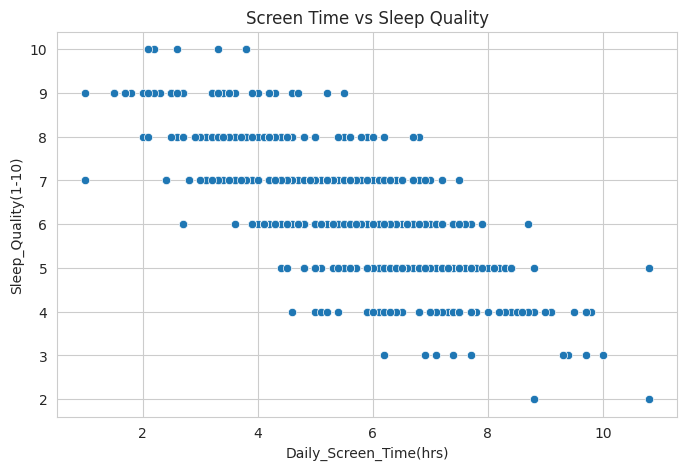

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Daily_Screen_Time(hrs)",
    y="Sleep_Quality(1-10)"
)

plt.title("Screen Time vs Sleep Quality")

plt.show()

**Interpretation**:

This scatter plot helps determine whether increased social media usage is associated with poorer sleep quality.

# **4. Which age group experiences the highest stress level?**

In [ ]:
bins = [0,18,25,35,50,100]

labels = [
    "Teen",
    "Young Adult",
    "Adult",
    "Middle Age",
    "Senior"
]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

In [ ]:
df.groupby("Age_Group")["Stress_Level(1-10)"].mean()

/tmp/ipykernel_1620/3048521168.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Group")["Stress_Level(1-10)"].mean()


,Stress_Level(1-10)
Age_Group,
Teen,6.460000
Young Adult,6.566667
Adult,6.776119
Middle Age,6.579646
Senior,NaN


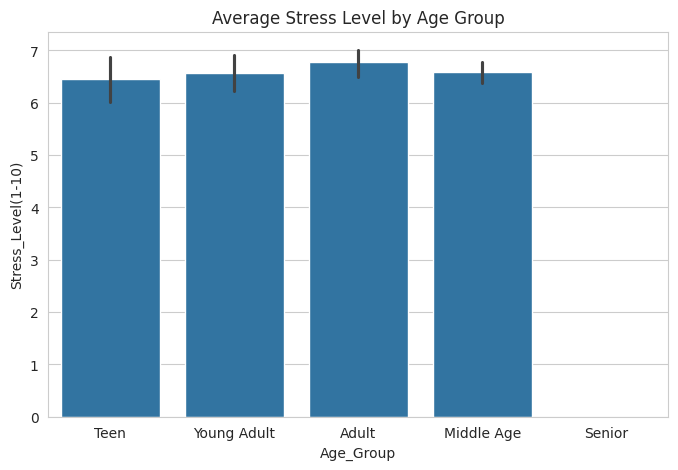

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Age_Group",
    y="Stress_Level(1-10)"
)

plt.title("Average Stress Level by Age Group")

plt.show()

**Interpretation:**

This analysis compares stress levels across different age groups.

# **5. Do stress levels differ across genders?**

In [ ]:
df.groupby("Gender")["Stress_Level(1-10)"].mean()

,Stress_Level(1-10)
Gender,
Female,6.602620
Male,6.633065
Other,6.608696


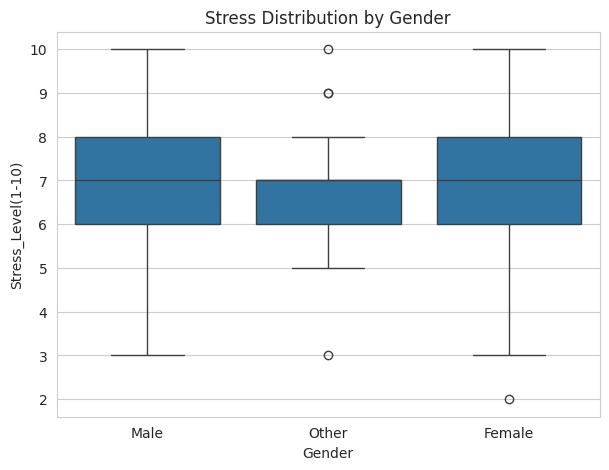

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Stress_Level(1-10)"
)

plt.title("Stress Distribution by Gender")

plt.show()

**Interpretation:**

This analysis investigates whether stress levels differ among gender.

# **6. Which platform users report the worst sleep quality?**

In [ ]:
platform_sleep = (
    df.groupby("Social_Media_Platform")["Sleep_Quality(1-10)"]
    .mean()
    .sort_values()
)

platform_sleep

,Sleep_Quality(1-10)
Social_Media_Platform,
Instagram,5.905405
Facebook,6.098765
YouTube,6.333333
X (Twitter),6.386364
TikTok,6.463158
LinkedIn,6.551724


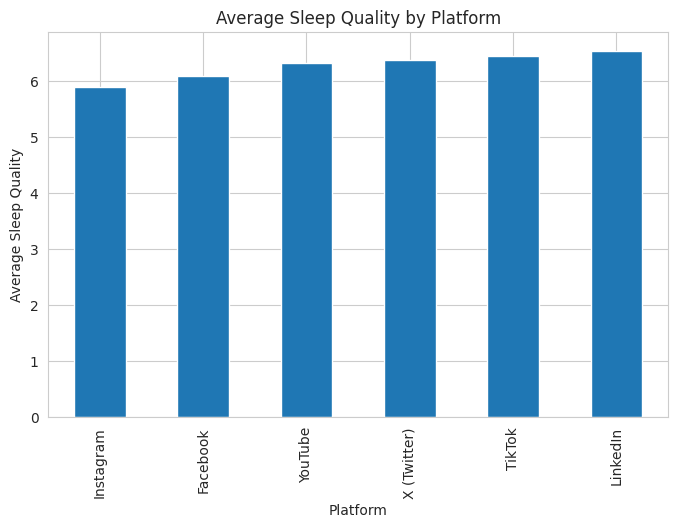

In [ ]:
plt.figure(figsize=(8,5))

platform_sleep.plot(kind="bar")

plt.title("Average Sleep Quality by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Sleep Quality")

plt.show()

**Interpretation:**

This analysis compares sleep quality among users of different social media platforms.

# **7. Which platform-age group combination shows the highest stress level?**

In [ ]:
highest_combo = (
    df.groupby(
        ["Social_Media_Platform", "Age_Group"],
        observed=False
    )["Stress_Level(1-10)"]
    .mean()
    .sort_values(ascending=False)
)

highest_combo.head(10)

Social_Media_Platform  Age_Group  
Instagram              Young Adult    7.818182
Facebook               Young Adult    7.181818
TikTok                 Adult          7.040000
Instagram              Teen           7.000000
                       Adult          6.952381
YouTube                Teen           6.900000
Facebook               Adult          6.846154
X (Twitter)            Adult          6.814815
LinkedIn               Middle Age     6.702128
Instagram              Middle Age     6.694444
Name: Stress_Level(1-10), dtype: float64

**Interpretation:**

This analysis identifies the most vulnerable age group and platform combination.

# **Research Question:**

1. Does higher screen time lead to higher stress levels?
2. Which social media platform has the highest average stress level?
3. Does increased screen time affect sleep quality?
4. Which age group experiences the highest stress level?
5. Do stress levels differ across genders?
6. Which platform users report the worst sleep quality?
7. Which platform-age group combination shows the highest stress level?

# **Key Finding:**

1. Users with higher daily screen time generally reported higher stress levels compared to low-usage users.

2. Instagram users reported the highest average stress levels among all platforms.

3. Higher screen time was associated with poorer sleep quality.

4. Young Adults showed relatively higher stress levels compared to other age groups.

5. Stress levels varied slightly across genders, indicating demographic differences in social media experiences.

6. Sleep quality differed across platforms, with some platforms showing lower average sleep quality scores.

7. Instagram users in the Young Adult age group reported the highest average stress level (7.82), making them the most vulnerable group identified in this study.

# **Overall Conclusion:**

This study found that social media usage patterns are associated with stress levels and sleep quality. Higher screen time was generally linked to increased stress and reduced sleep quality. Among all groups, Instagram users in the Young Adult category showed the highest average stress level. These findings highlight the importance of balanced social media usage and healthy digital habits.

# **Recommendations:**

1. Users should monitor and limit excessive daily social media usage to reduce stress levels.

2. Avoiding prolonged social media use before bedtime may help improve sleep quality.

3. Using screen-time management tools and digital wellbeing features can encourage healthier online habits.

4. Young adults, especially heavy Instagram users, should be encouraged to maintain a balance between online and offline activities.

5. Future studies can include additional mental health indicators such as anxiety and depression scores for deeper analysis.

# **Thank You.**